# Co-Authorship Network and Research Community Detection
Alex Bradshaw, 1861973

Julien Garcia, 2017699

## About
The goal of this analysis is to map co-author relationsihps across venues.

## Tasks
- Map co-author networks within and across venues/conferences
- Use graph clustering to identify research communities/groups
- Analyze collaboration patterns (do certain author groups dominate certain venues?)

## Motivations
- Identify tight-knit research communities and key bridge figures who connect disparate groups
- Understand collaboration culture: do certain venues/subfields favor collaboration while others are individual-focused?
- Discover hidden research hierarchies: who are the central figures in each community? How do newcomers break in?
- Reveal informal networks: papers often come from established research groups; understanding these networks provides insights into how research is actually conducted

## Challenges
- Author disambiguation: Same name can refer to different authors; misspellings and name variations make exact matching difficult
- Scale variation: Some authors publish 100+ papers, others 1-2; co-authorship graph has highly skewed degree distribution
- Temporal changes: Research communities evolve; some authors exit, new collaborators emerge; static snapshots miss this dynamic
- Defining "communities": Different clustering algorithms (Louvain, K-clique, etc.) can yield very different community structures

In [1]:
"""Import Dependencies"""
import json
import os
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

In [7]:
"""Globals/Constants"""
DATA_PATH = './dblp_ref/'

In [8]:
"""Helper/Utility Functions"""
def read_json_lines(file_path):
    """Reads the JSON file at the given path and yeilds each line (record)."""
    with open(file_path) as json_file:
        for line in json_file:
            yield json.loads(line)

In [9]:
"""Load Data"""
frames = []
for file_index in range(4):
    file_name = f'{ DATA_PATH }dblp-ref-{ file_index }.json'
    print(f"Loading file { file_name } ({ file_index + 1 }/4)...")
    frames.append(pd.DataFrame(read_json_lines(file_name)))

print("Concatenating Data Frames...")
papers = pd.concat(frames)
papers

Loading file ./dblp_ref/dblp-ref-0.json (1/4)...


FileNotFoundError: [Errno 2] No such file or directory: './dblp_ref/dblp-ref-0.json'

/tmp/ipykernel_85132/998368959.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab20', max(1, len(unique_venues)))


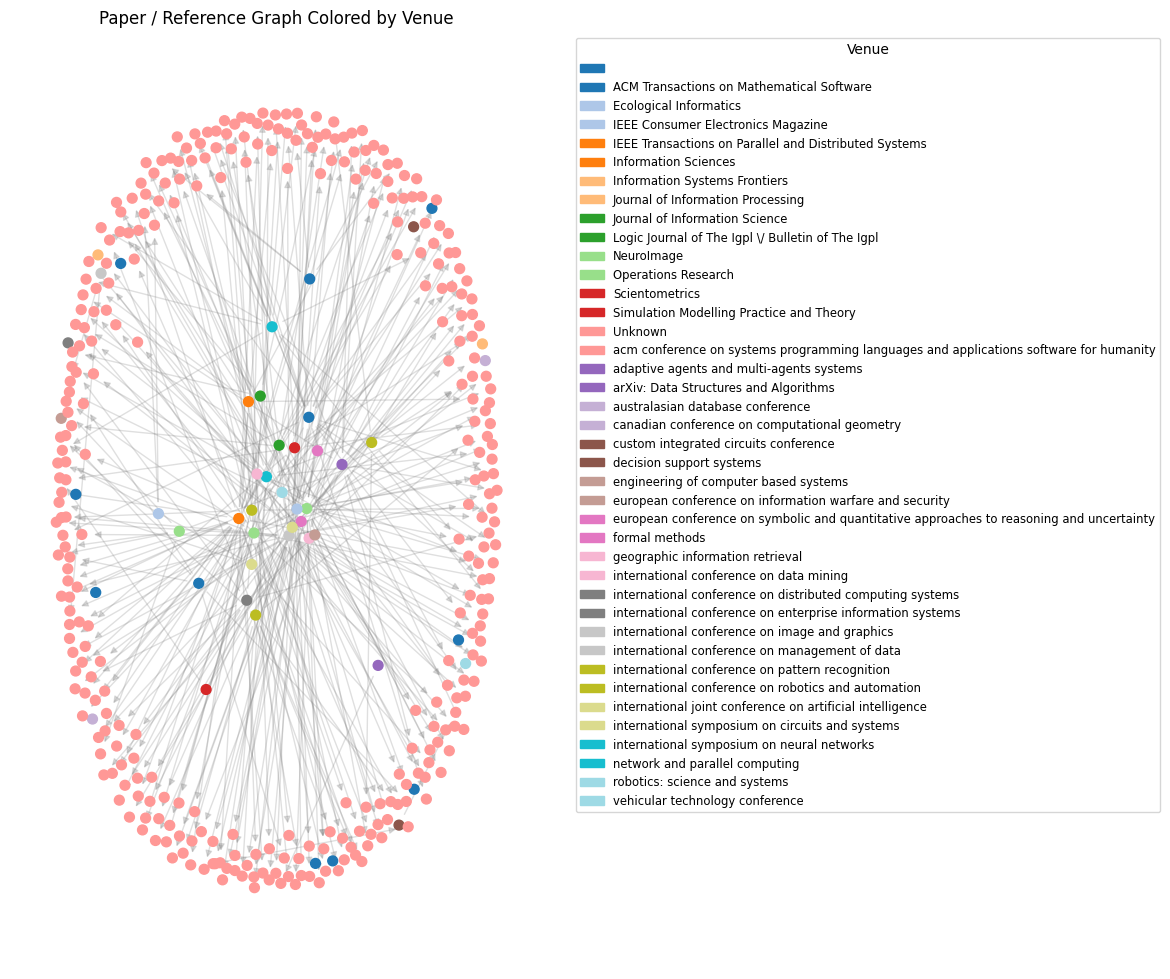

In [33]:
"""Task 1: Map Co-Author Networks Within and Across Venues/Conferences"""
graph = nx.DiGraph()

papers_100 = papers.dropna(subset=['venue']).sample(50)

graph.add_node(1)
graph.add_nodes_from(papers_100['id'])
for paper in papers_100.itertuples():
    if isinstance(paper.references, list):
        for reference in paper.references:
            graph.add_edge(paper.id, reference)

# nx.draw(graph, with_labels=False, node_size=10)
        
venue_by_id = papers_100.set_index('id')['venue'].fillna('Unknown').to_dict()
venue_values = [venue_by_id.get(node, 'Unknown') for node in graph.nodes()]
unique_venues = sorted(set(venue_values))
color_map = plt.cm.get_cmap('tab20', max(1, len(unique_venues)))
venue_to_color = {venue: color_map(i) for i, venue in enumerate(unique_venues)}
node_colors = [venue_to_color[venue] for venue in venue_values]

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(graph, seed=42, k=0.5)
nx.draw_networkx_edges(graph, pos, alpha=0.25, edge_color='gray')
nx.draw_networkx_nodes(graph, pos, node_color=node_colors, node_size=50)
plt.title('Paper / Reference Graph Colored by Venue')
plt.axis('off')

from matplotlib.patches import Patch
legend_handles = [Patch(color=venue_to_color[venue], label=venue) for venue in unique_venues]
plt.legend(handles=legend_handles, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', title='Venue')

plt.tight_layout()
plt.show()

# for paper in papers.itertuples():
#     if paper.n_citation == 0:
#         print(paper.title)


### Julien Garcia
2017699

### About
This section identifies emerging research topics in the DBLP dataset by analyzing paper titles, abstracts, years, and venues. The goal is to discover major research themes, track how they change over time, and compare how quickly different venues adopt those topics.

### Tasks
- use TF-IDF features from paper titles and abstracts
- apply topic modeling to discover latent research themes
- track topic prevalence from 2000 to 2017
- identify topics that grew the most over time
- compare topic adoption across major venues
- use representative papers as case studies


In [2]:
"constants"
START_YEAR = 2000
END_YEAR = 2017

MAX_FEATURES = 5000
NUM_TOPICS = 10
TOP_WORDS_PER_TOPIC = 12

# sample
SAMPLE_SIZE = 100000

RANDOM_STATE = 42

In [5]:
"helper functions"
def get_top_words(model, feature_names, n_words=10):
    #gets the main words for each topic
    rows = []
    for topic_index, topic_weights in enumerate(model.components_):
        top_indices = topic_weights.argsort()[::-1][:n_words]
        top_words = [feature_names[i] for i in top_indices]

        rows.append({
            "topic_id": topic_index,
            "top_words": ", ".join(top_words)
        })
    return pd.DataFrame(rows)

def label_topic(top_words):
    words = top_words.lower()
    if any(term in words for term in ["neural", "deep", "learning", "classification", "prediction"]):
        return "machine learning"
    elif any(term in words for term in ["image", "vision", "recognition", "object", "feature"]):
        return "computer vision"
    elif any(term in words for term in ["data", "mining", "query", "database", "web"]):
        return "data mining databases"
    elif any(term in words for term in ["wireless", "sensor", "routing", "mobile", "network"]):
        return "networks wireless systems"
    elif any(term in words for term in ["software", "program", "code", "testing"]):
        return "software engineering"
    elif any(term in words for term in ["security", "privacy", "attack", "encryption"]):
        return "security privacy"
    elif any(term in words for term in ["cloud", "distributed", "parallel", "computing"]):
        return "distributed cloud computing"
    elif any(term in words for term in ["social", "user", "recommendation", "online"]):
        return "social recommender systems"
    else:
        return "mixed topic"

In [6]:
"clean data for my topic analysis"
topic_papers = papers.copy()

# need title abstract and year for this part
topic_papers = topic_papers.dropna(subset=["title", "abstract", "year"])
# looking at 2000 to 2017
topic_papers = topic_papers[
    (topic_papers["year"] >= START_YEAR) &
    (topic_papers["year"] <= END_YEAR)
]
# keep venue for later
topic_papers["venue"] = topic_papers["venue"].fillna("").astype(str)
# combine title and abstract since both describe the paper
topic_papers["text"] = (
    topic_papers["title"].astype(str) + " " +
    topic_papers["abstract"].astype(str)
)
# remove short ones
topic_papers["text_length"] = topic_papers["text"].str.split().str.len()
topic_papers = topic_papers[topic_papers["text_length"] >= 20]
print("filtered papers:", topic_papers.shape)
topic_papers[["title", "venue", "year", "n_citation", "text_length"]].head()

NameError: name 'papers' is not defined

In [ ]:
"sample data"
if SAMPLE_SIZE is not None and len(topic_papers) > SAMPLE_SIZE:
    topic_sample = topic_papers.sample(
        n=SAMPLE_SIZE,
        random_state=RANDOM_STATE
    ).copy()
else:
    topic_sample = topic_papers.copy()
print("sample size:", topic_sample.shape)

In [ ]:
"make tfidf features"
vectorizer = TfidfVectorizer(
    max_features=MAX_FEATURES,
    stop_words="english",
    lowercase=True,
    min_df=10,
    max_df=0.80
)
tfidf_matrix = vectorizer.fit_transform(topic_sample["text"])
print("tfidf shape:", tfidf_matrix.shape)

In [ ]:
"run topic model"
topic_model = NMF(
    n_components=NUM_TOPICS,
    random_state=RANDOM_STATE,
    init="nndsvda",
    max_iter=300
)
document_topic_matrix = topic_model.fit_transform(tfidf_matrix)
print("document topic shape:", document_topic_matrix.shape)

In [ ]:
"show topic words"
feature_names = vectorizer.get_feature_names_out()
topic_keywords = get_top_words(
    topic_model,
    feature_names,
    n_words=TOP_WORDS_PER_TOPIC
)
topic_keywords["topic_label"] = topic_keywords["top_words"].apply(label_topic)
topic_keywords

In [ ]:
"give each paper its strongest topic"
topic_sample["dominant_topic"] = document_topic_matrix.argmax(axis=1)
topic_sample["dominant_topic_weight"] = document_topic_matrix.max(axis=1)
topic_sample = topic_sample.merge(
    topic_keywords[["topic_id", "topic_label"]],
    left_on="dominant_topic",
    right_on="topic_id",
    how="left"
)
topic_sample[[
    "title",
    "venue",
    "year",
    "n_citation",
    "dominant_topic",
    "topic_label",
    "dominant_topic_weight"
]].head()

In [ ]:
"count topics"
topic_counts = (
    topic_sample["topic_label"]
    .value_counts()
    .reset_index()
)
topic_counts.columns = ["topic_label", "paper_count"]
topic_counts["percentage"] = (
    topic_counts["paper_count"] /
    topic_counts["paper_count"].sum() *
    100
)
topic_counts

In [ ]:
"plot topic counts"
plt.figure(figsize=(12, 6))
plt.bar(topic_counts["topic_label"], topic_counts["paper_count"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("topic")
plt.ylabel("number of papers")
plt.title("topic counts")
plt.tight_layout()
plt.show()

In [ ]:
"topic counts by year"
year_topic_counts = (
    topic_sample
    .groupby(["year", "topic_label"])
    .size()
    .reset_index(name="paper_count")
)
year_totals = (
    topic_sample
    .groupby("year")
    .size()
    .reset_index(name="year_total")
)
year_topic_counts = year_topic_counts.merge(year_totals, on="year", how="left")
year_topic_counts["topic_percentage"] = (
    year_topic_counts["paper_count"] /
    year_topic_counts["year_total"] *
    100
)
year_topic_counts.head()

In [ ]:
"plot topics over time"
plt.figure(figsize=(14, 7))

for topic_label in sorted(year_topic_counts["topic_label"].unique()):
    topic_trend = year_topic_counts[
        year_topic_counts["topic_label"] == topic_label
    ]
    plt.plot(
        topic_trend["year"],
        topic_trend["topic_percentage"],
        marker="o",
        label=topic_label
    )
plt.xlabel("year")
plt.ylabel("percent of papers")
plt.title("topics over time")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
"find topics that grew the most"
early_period = topic_sample[
    (topic_sample["year"] >= 2000) &
    (topic_sample["year"] <= 2005)
]
late_period = topic_sample[
    (topic_sample["year"] >= 2012) &
    (topic_sample["year"] <= 2017)
]
early_topic_share = (
    early_period["topic_label"]
    .value_counts(normalize=True)
    .reset_index()
)
early_topic_share.columns = ["topic_label", "early_share"]
late_topic_share = (
    late_period["topic_label"]
    .value_counts(normalize=True)
    .reset_index()
)
late_topic_share.columns = ["topic_label", "late_share"]
topic_growth = topic_keywords[["topic_label"]].drop_duplicates()
topic_growth = topic_growth.merge(early_topic_share, on="topic_label", how="left")
topic_growth = topic_growth.merge(late_topic_share, on="topic_label", how="left")
topic_growth["early_share"] = topic_growth["early_share"].fillna(0)
topic_growth["late_share"] = topic_growth["late_share"].fillna(0)
topic_growth["growth_change"] = topic_growth["late_share"] - topic_growth["early_share"]
topic_growth["growth_percentage_points"] = topic_growth["growth_change"] * 100
topic_growth = topic_growth.sort_values(
    "growth_percentage_points",
    ascending=False
)
topic_growth

In [ ]:
"plot growing topics"
top_growth = topic_growth.head(8)
plt.figure(figsize=(12, 6))
plt.bar(top_growth["topic_label"], top_growth["growth_percentage_points"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("topic")
plt.ylabel("growth percentage points")
plt.title("fastest growing topics")
plt.tight_layout()
plt.show()

In [ ]:
"topic lifecycle table"
topic_lifecycle_rows = []
for topic_label in sorted(year_topic_counts["topic_label"].unique()):
    trend = year_topic_counts[
        year_topic_counts["topic_label"] == topic_label
    ].copy()
    peak_row = trend.loc[trend["topic_percentage"].idxmax()]
    early_avg = trend[trend["year"].between(2000, 2005)]["topic_percentage"].mean()
    middle_avg = trend[trend["year"].between(2006, 2011)]["topic_percentage"].mean()
    late_avg = trend[trend["year"].between(2012, 2017)]["topic_percentage"].mean()
    topic_lifecycle_rows.append({
        "topic_label": topic_label,
        "peak_year": int(peak_row["year"]),
        "peak_percentage": peak_row["topic_percentage"],
        "early_avg_percentage": early_avg,
        "middle_avg_percentage": middle_avg,
        "late_avg_percentage": late_avg
    })
topic_lifecycle = pd.DataFrame(topic_lifecycle_rows)
topic_lifecycle = topic_lifecycle.sort_values(
    "late_avg_percentage",
    ascending=False
)
topic_lifecycle

In [ ]:
"look at topics by venue"
venue_counts = (
    topic_sample[topic_sample["venue"] != ""]
    ["venue"]
    .value_counts()
)
top_venues = venue_counts.head(10).index.tolist()
venue_topic_data = topic_sample[
    topic_sample["venue"].isin(top_venues)
].copy()
venue_topic_counts = (
    venue_topic_data
    .groupby(["venue", "topic_label"])
    .size()
    .reset_index(name="paper_count")
)
venue_totals = (
    venue_topic_data
    .groupby("venue")
    .size()
    .reset_index(name="venue_total")
)
venue_topic_counts = venue_topic_counts.merge(
    venue_totals,
    on="venue",
    how="left"
)
venue_topic_counts["topic_percentage"] = (
    venue_topic_counts["paper_count"] /
    venue_topic_counts["venue_total"] *
    100
)
venue_topic_counts.head()

In [ ]:
"venue topic table"
venue_topic_pivot = venue_topic_counts.pivot_table(
    index="venue",
    columns="topic_label",
    values="topic_percentage",
    fill_value=0
)
venue_topic_pivot

In [ ]:
"plot top growing topics by venue"
selected_topics = topic_growth.head(4)["topic_label"].tolist()
for selected_topic in selected_topics:
    plot_data = venue_topic_counts[
        venue_topic_counts["topic_label"] == selected_topic
    ].sort_values("topic_percentage", ascending=False)
    plt.figure(figsize=(12, 6))
    plt.bar(plot_data["venue"], plot_data["topic_percentage"])
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("venue")
    plt.ylabel("percent of venue papers")
    plt.title(f"venue adoption for {selected_topic}")
    plt.tight_layout()
    plt.show()

In [ ]:
"case study papers"
case_study_rows = []
for topic_label in topic_growth.head(5)["topic_label"]:
    topic_examples = (
        topic_sample[topic_sample["topic_label"] == topic_label]
        .sort_values(
            ["dominant_topic_weight", "n_citation"],
            ascending=False
        )
        .head(3)
    )
    for _, row in topic_examples.iterrows():
        case_study_rows.append({
            "topic_label": topic_label,
            "title": row["title"],
            "venue": row["venue"],
            "year": row["year"],
            "n_citation": row["n_citation"],
            "topic_weight": row["dominant_topic_weight"]
        })
case_studies = pd.DataFrame(case_study_rows)
case_studies

In [ ]:
"case study papers"
case_study_rows = []
for topic_label in topic_growth.head(5)["topic_label"]:
    topic_examples = (
        topic_sample[topic_sample["topic_label"] == topic_label]
        .sort_values(
            ["dominant_topic_weight", "n_citation"],
            ascending=False
        )
        .head(3)
    )
    for _, row in topic_examples.iterrows():
        case_study_rows.append({
            "topic_label": topic_label,
            "title": row["title"],
            "venue": row["venue"],
            "year": row["year"],
            "n_citation": row["n_citation"],
            "topic_weight": row["dominant_topic_weight"]
        })
case_studies = pd.DataFrame(case_study_rows)
case_studies

In [ ]:
"save tables"
os.makedirs("outputs", exist_ok=True)
topic_keywords.to_csv("outputs/emerging_topic_keywords.csv", index=False)
topic_growth.to_csv("outputs/emerging_topic_growth.csv", index=False)
topic_lifecycle.to_csv("outputs/emerging_topic_lifecycle.csv", index=False)
venue_topic_pivot.to_csv("outputs/venue_topic_adoption.csv")
case_studies.to_csv("outputs/emerging_topic_case_studies.csv", index=False)
print("saved tables")